In [1]:
from torch.utils.data import Dataset, DataLoader
import torch
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, HDBSCAN
# GaussianMixture
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
# import
from hmmlearn.hmm import GaussianHMM


In [2]:
device ="mps"

In [3]:
with open('../../data/nifty_ts2vec.pkl', 'rb') as f:
    data = pd.read_pickle(f)

In [4]:
df=data.copy()
data=data.drop("Close",axis=1)

In [27]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, data, window_size=60):
        """
        data: numpy array [T, D]
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        return x

window_size = 60
val_size = 0

train_size = int(len(data) * (1 - val_size))
train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:]

train_dataset = TimeSeriesWindowDataset(train_data.values, window_size)
val_dataset = TimeSeriesWindowDataset(val_data.values, window_size)
combined_dataset = TimeSeriesWindowDataset(data.values, window_size)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
combined_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=False)



In [42]:
len(combined_dataset)

4240

In [28]:
for batch in train_loader:
    print(batch.shape)  # Should print torch.Size([32, 60, D])
    break

torch.Size([32, 60, 12])


In [29]:
import torch.nn as nn
import torch.nn.functional as F

class TS2VecModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=5):
        super(TS2VecModel, self).__init__()
        layers = []
        for i in range(num_layers):
            dilation = 2 ** i
            layers.append(nn.Conv1d(input_dim if i == 0 else hidden_dim, hidden_dim, kernel_size=3, padding=dilation, dilation=dilation))
            layers.append(nn.ReLU())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # x: [B, T, D]
        x = x.permute(0, 2, 1)  # [B, D, T]
        x = self.network(x)     # [B, H, T]
        x = x.permute(0, 2, 1)  # [B, T, H]
        # normalize
        x = F.normalize(x, p=2, dim=-1)
        return x

In [30]:
data.shape

(4300, 12)

In [33]:
model = TS2VecModel(input_dim=data.shape[1], hidden_dim=64, num_layers=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [34]:
model

TS2VecModel(
  (network): Sequential(
    (0): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (3): ReLU()
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (5): ReLU()
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (7): ReLU()
    (8): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
    (9): ReLU()
  )
)

In [35]:
def time_mask(x, mask_ratio=0.2):
    B, T, D = x.shape
    mask_len = int(T * mask_ratio)
    start = np.random.randint(0, T - mask_len)
    x = x.clone()
    x[:, start:start+mask_len, :] = 0
    return x

def temporal_negative_mask(B, T, exclusion_radius, device):
    """
    Returns mask of shape [B*T, B*T]
    True = allowed negative
    False = masked out
    """
    BT = B * T
    mask = torch.ones(BT, BT, device=device, dtype=torch.bool)

    for b in range(B):
        for t in range(T):
            idx = b*T + t
            start = max(0, t - exclusion_radius)
            end   = min(T, t + exclusion_radius + 1)
            for tt in range(start, end):
                mask[idx, b*T + tt] = False

    return mask



def jitter(x, sigma=0.02):
    return x + sigma * torch.randn_like(x)


# def temporal_pooling(z):
#     """
#     z: [B, T, C]
#     returns: [B, T//2, C]
#     """
#     if z.size(1) % 2 == 1:
#         z = z[:, :-1, :]
#     z = z.reshape(z.size(0), z.size(1)//2, 2, z.size(2))
#     return z.max(dim=2).values

def temporal_pooling(z):
    if z.size(1) % 2 == 1:
        z = z[:, :-1]
    return z.reshape(z.size(0), z.size(1)//2, 2, z.size(2)).mean(dim=2)

def instance_contrastive_loss(z1, z2, temperature=0.1):
    """
    z1, z2: [B, T, C]
    """
    B, T, C = z1.shape

    z1 = z1.reshape(B*T, C)
    z2 = z2.reshape(B*T, C)

    sim = torch.matmul(z1, z2.T) / temperature  # [BT, BT]
    labels = torch.arange(B*T, device=device)
    
    return F.cross_entropy(sim, labels)
    
def masked_instance_contrastive_loss(
    z1, z2, exclusion_radius=5, temperature=0.1
):
    B, T, C = z1.shape
    z1 = z1.reshape(B*T, C)
    z2 = z2.reshape(B*T, C)

    sim = torch.matmul(z1, z2.T) / temperature
    mask = temporal_negative_mask(B, T, exclusion_radius, z1.device)

    # mask invalid negatives
    sim = sim.masked_fill(~mask, -1e9)

    labels = torch.arange(B*T, device=z1.device)
    return F.cross_entropy(sim, labels)

def hierarchical_contrastive_loss(z1, z2, temperature=0.1, min_time=2):
    """
    z1, z2: [B, T, C]
    """
    total_loss = 0.0
    depth = 0

    while z1.size(1) >= min_time:
        loss = instance_contrastive_loss(z1, z2, temperature)
        total_loss += loss

        # downsample
        z1 = temporal_pooling(z1)
        z2 = temporal_pooling(z2)
        depth += 1

    return total_loss / depth

def ts2vec_contrastive_loss(
    z1, z2,
    temperature=0.1,
    exclusion_radius=5
):
    """
    z1, z2: [B, T, C]
    """
    B, T, C = z1.shape
    loss = 0.0
    count = 0

    for t in range(T):
        pos_sim = F.cosine_similarity(
            z1[:, t], z2[:, t], dim=-1
        ) / temperature  # [B]

        # negatives: all other timestamps except nearby
        neg_sims = []
        for tt in range(T):
            if abs(tt - t) > exclusion_radius:
                neg = F.cosine_similarity(
                    z1[:, t].unsqueeze(1),
                    z2[:, tt].unsqueeze(0),
                    dim=-1
                ) / temperature
                neg_sims.append(neg)

        if len(neg_sims) == 0:
            continue

        neg_sims = torch.cat(neg_sims, dim=1)

        logits = torch.cat(
            [pos_sim.unsqueeze(1), neg_sims], dim=1
        )

        labels = torch.zeros(B, dtype=torch.long, device=z1.device)
        loss += F.cross_entropy(logits, labels)
        count += 1

    return loss / count

def ts2vec_contrastive_loss_vectorized(
    z1, z2,
    temperature=0.1,
    base_exclusion_radius=5
):
    """
    z1, z2: [B, T, C]
    """
    B, T, C = z1.shape
    device = z1.device

    # flatten (instance, time)
    z1_flat = z1.reshape(B*T, C)
    z2_flat = z2.reshape(B*T, C)

    # cosine similarity == dot product because embeddings are normalized
    sim = torch.matmul(z1_flat, z2_flat.T) / temperature   # [BT, BT]

    # ----- temporal negative mask -----
    exclusion_radius = min(base_exclusion_radius, (T - 1) // 2)

    if exclusion_radius == 0:
        return torch.tensor(0.0, device=device)

    # time index per row
    time_idx = torch.arange(T, device=device).repeat(B)     # [BT]

    # batch index per row
    batch_idx = torch.arange(B, device=device).repeat_interleave(T)

    # same batch & temporally close → mask out
    temporal_dist = torch.abs(time_idx[:, None] - time_idx[None, :])
    same_batch = batch_idx[:, None] == batch_idx[None, :]

    invalid_negatives = same_batch & (temporal_dist <= exclusion_radius)

    # allow diagonal (positive pairs)
    diag = torch.eye(B*T, device=device, dtype=torch.bool)
    invalid_negatives = invalid_negatives & (~diag)

    # mask invalid negatives
    sim = sim.masked_fill(invalid_negatives, -1e9)

    # positives are diagonal
    labels = torch.arange(B*T, device=device)

    return F.cross_entropy(sim, labels)


def hierarchical_ts2vec_loss(
    z1, z2,
    temperature=0.1,
    exclusion_radius=5,
    min_time=2
):
    total_loss = 0.0
    depth = 0

    while z1.size(1) >= min_time:
        total_loss += ts2vec_contrastive_loss_vectorized(
            z1, z2,
            temperature,
            exclusion_radius
        )

        z1 = temporal_pooling(z1)
        z2 = temporal_pooling(z2)
        depth += 1

    return total_loss / depth

def hierarchical_ts2vec_loss_v2(
    z1, z2,
    temperature=0.1,
    exclusion_radius=5,
    min_time=2
):
    total_loss = 0.0
    depth = 0

    while z1.size(1) >= min_time:
        T = z1.size(1)

        if T > 2 * exclusion_radius + 1:
            total_loss += ts2vec_contrastive_loss_vectorized(
                z1, z2,
                temperature,
                exclusion_radius
            )
            depth += 1

        z1 = temporal_pooling(z1)
        z2 = temporal_pooling(z2)

    return total_loss / max(depth, 1)



def embedding_variance(z):
    # z: [B, T, C]
    return z.var(dim=0).mean().item() # mean over T and C


In [36]:
%%time
# embedding_variance_1 = []
# embedding_variance_2 = []
for epoch in range(20):
    total_loss = 0
    model.train()
    for x in train_loader:
        x=x.to(device)
        x1 = jitter(time_mask(x))
        x2 = jitter(time_mask(x))
        z1 = model(x1)
        z2 = model(x2)

        # embedding_variance_1.append(embedding_variance(z1))
        # embedding_variance_2.append(embedding_variance(z2))

        loss = hierarchical_ts2vec_loss_v2(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # print(f"Batch Loss: {loss.item():.4f}")
    # model.eval()
    # with torch.no_grad():
    #     val_loss = 0
    #     for x in val_loader:
    #         x = x.to(device)
    #         x1 = jitter(time_mask(x))
    #         x2 = jitter(time_mask(x))
    #         z1 = model(x1)
    #         z2 = model(x2)
    #         val_loss += hierarchical_ts2vec_loss_v2(z1, z2).item()

    # val_loss /= len(val_loader)

    print(f"Epoch {epoch}, Loss {total_loss / len(train_loader):.4f}")

Epoch 0, Loss 1.9469
Epoch 1, Loss 1.0484
Epoch 2, Loss 0.8830
Epoch 3, Loss 0.8053
Epoch 4, Loss 0.7671
Epoch 5, Loss 0.7183
Epoch 6, Loss 0.6937
Epoch 7, Loss 0.6728
Epoch 8, Loss 0.6614
Epoch 9, Loss 0.6510
Epoch 10, Loss 0.6347
Epoch 11, Loss 0.6234
Epoch 12, Loss 0.6103
Epoch 13, Loss 0.5952
Epoch 14, Loss 0.5924
Epoch 15, Loss 0.5941
Epoch 16, Loss 0.5789
Epoch 17, Loss 0.5732
Epoch 18, Loss 0.5622
Epoch 19, Loss 0.5597
CPU times: user 21.2 s, sys: 4.11 s, total: 25.3 s
Wall time: 22.1 s


In [37]:
# save model
torch.save(model.state_dict(), './../../models/ts2vec_nifty.pth')

In [38]:
# load model
# model.load_state_dict(torch.load('./ts2vec_nifty.pth'))

In [39]:
# model.eval()
# all_embeddings = []

# with torch.inference_mode():
#     for x in val_loader:
#         # print("x.shape", x.shape)
#         x = x.to(device)    
#         z = model(x)          # [B, T, C]
#         z_mean = z.mean(dim=1)  # [B, C]
#         all_embeddings.append(z_mean)

# embeddings = torch.cat(all_embeddings).cpu().numpy()

In [40]:
all_embeddings = []
with torch.inference_mode():
    for x in combined_loader:
        # print("x.shape", x.shape)
        x = x.to(device)    
        z = model(x)          # [B, T, C]
        z_mean = z.mean(dim=1)  # [B, C]
        all_embeddings.append(z_mean)

embeddings_full = torch.cat(all_embeddings).cpu().numpy()

In [41]:
len(embeddings_full)

4240

In [14]:
# full_df = data.iloc[window_size - 1 : ].copy()
# full_df.shape, embeddings_full.shape

In [43]:
val_df = pd.DataFrame(
    embeddings_full,
    index=data.index[window_size - 1 : window_size - 1 + len(embeddings_full)]
)

In [47]:
val_df["Close"] = df["Close"].iloc[window_size - 1 : window_size - 1 + len(embeddings_full)].values

In [48]:
val_df

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,Close
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-05 00:00:00+05:30,0.000000,0.094707,0.000000,0.086095,0.000000,0.052627,0.000000,0.034146,0.049268,0.079448,...,0.000000,0.007209,0.042414,0.000000,0.000000,0.097714,0.014177,0.101710,0.000000,4676.950195
2008-06-06 00:00:00+05:30,0.000000,0.096463,0.000000,0.093592,0.000000,0.055477,0.000000,0.038427,0.048164,0.072977,...,0.000000,0.004996,0.039518,0.000000,0.000000,0.092051,0.016242,0.101359,0.000000,4627.799805
2008-06-09 00:00:00+05:30,0.000000,0.097814,0.000000,0.100934,0.000000,0.060673,0.000000,0.042575,0.046727,0.065568,...,0.000000,0.002542,0.034720,0.000000,0.000000,0.085397,0.017465,0.100786,0.000000,4500.950195
2008-06-10 00:00:00+05:30,0.000000,0.099855,0.000000,0.104100,0.000000,0.071059,0.000000,0.047309,0.046517,0.058178,...,0.000000,0.001713,0.030261,0.000000,0.000000,0.080686,0.019027,0.099659,0.000000,4449.799805
2008-06-11 00:00:00+05:30,0.000000,0.100483,0.000000,0.105155,0.000000,0.084748,0.000000,0.052642,0.045687,0.050810,...,0.000058,0.000870,0.026759,0.000000,0.000000,0.075993,0.020184,0.097661,0.000000,4523.600098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-12 00:00:00+05:30,0.150253,0.171876,0.110617,0.016477,0.000274,0.000000,0.104171,0.077467,0.020435,0.000000,...,0.073654,0.000000,0.000000,0.025725,0.050502,0.000000,0.019644,0.066028,0.036041,25114.000000
2025-09-15 00:00:00+05:30,0.140572,0.171512,0.102708,0.012511,0.000518,0.000000,0.113352,0.073049,0.019066,0.000000,...,0.072866,0.000000,0.000000,0.025318,0.053611,0.000000,0.021749,0.061992,0.034028,25069.199219
2025-09-16 00:00:00+05:30,0.128521,0.175892,0.093519,0.008835,0.000000,0.000000,0.121123,0.067323,0.016315,0.000000,...,0.075898,0.000000,0.000000,0.024032,0.058974,0.000000,0.025540,0.057928,0.034247,25239.099609


In [49]:
val_df.to_pickle('../../data/nifty_ts2vec_embeddings.pkl')

<Axes: title={'center': 'Variance of TS2Vec Embeddings over Time'}, xlabel='Date'>

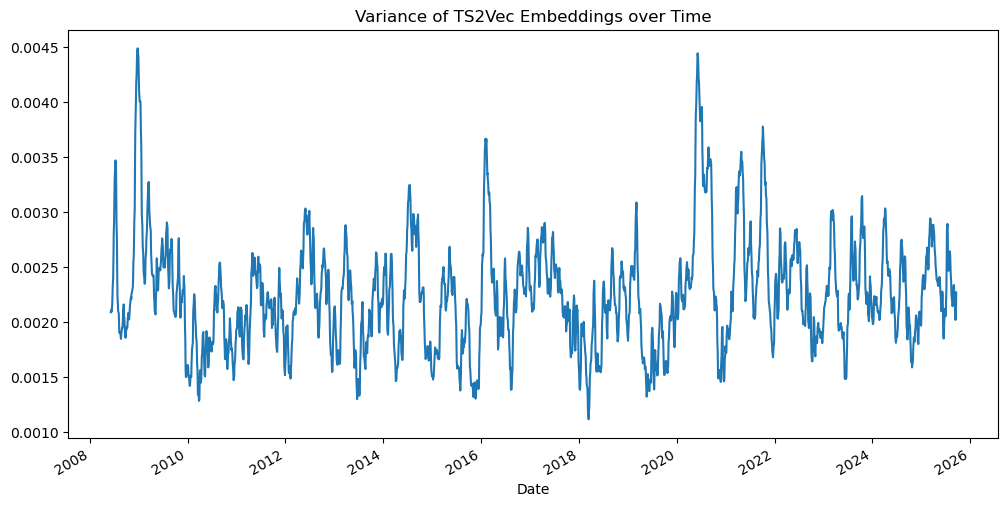

In [46]:
# variance of each sample
val_df.var(axis=1).plot(figsize=(12, 6), title='Variance of TS2Vec Embeddings over Time')

In [140]:
kmeans = KMeans(n_clusters=5, random_state=0)
labels = kmeans.fit_predict(embeddings_full)

In [147]:
hmm = GaussianHMM(n_components=5, covariance_type="full", n_iter=2000).fit(embeddings_full)
labels = hmm.predict(embeddings_full)

Model is not converging.  Current: 756733.4085045216 is not greater than 762136.5061415371. Delta is -5403.097637015511


In [71]:
# hdbscan clustering
clusterer = HDBSCAN(min_cluster_size=30, cluster_selection_method="leaf")
labels = clusterer.fit_predict(embeddings_full)

In [86]:
# GaussianMixture
gmm = GaussianMixture(n_components=3, covariance_type="full", max_iter=2000).fit(embeddings_full)
labels = gmm.predict(embeddings_full)

In [97]:
# probability of each cluster
probs = gmm.predict_proba(embeddings_full)
probs_df = pd.DataFrame(
    probs,
    index=data.index[window_size - 1 : window_size - 1 + len(embeddings_full)],
    columns=[f'Cluster_{i}_Prob' for i in range(probs.shape[1])]
)
probs_df

,Cluster_0_Prob,Cluster_1_Prob,Cluster_2_Prob
Date,,,
2008-03-07 00:00:00+05:30,0.0,1.0,0.0
2008-03-10 00:00:00+05:30,0.0,1.0,0.0
2008-03-11 00:00:00+05:30,0.0,1.0,0.0
2008-03-12 00:00:00+05:30,0.0,1.0,0.0
2008-03-13 00:00:00+05:30,0.0,1.0,0.0
...,...,...,...
2025-09-12 00:00:00+05:30,1.0,0.0,0.0
2025-09-15 00:00:00+05:30,1.0,0.0,0.0
2025-09-16 00:00:00+05:30,1.0,0.0,0.0


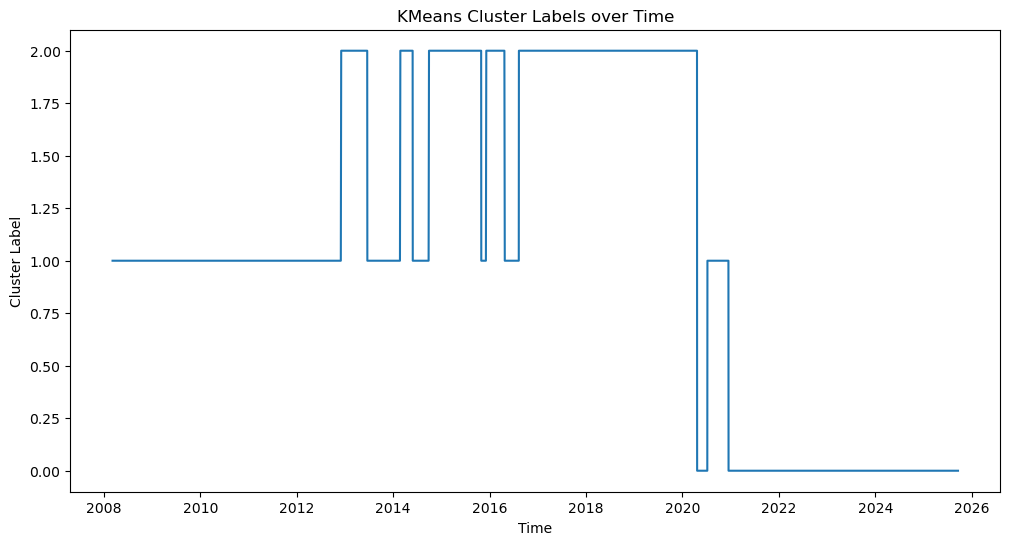

In [87]:
# plot the cluster labels over time
plt.figure(figsize=(12, 6))
plt.plot(val_df.index, labels)
plt.title('KMeans Cluster Labels over Time')
plt.xlabel('Time')
plt.ylabel('Cluster Label')
plt.show()

In [88]:
val_df["Close"] = df["Close"].iloc[window_size - 1 : window_size - 1 + len(embeddings_full)].values
val_df["Cluster"] = labels

In [89]:
# nifty_obj = yf.Ticker('^NSEI')
# nifty_data = nifty_obj.history(start=val_df.index[0], end=val_df.index[-1])

In [90]:
# nifty_data

In [91]:
# # merge cluster labels with nifty close prices
# nifty_merge = nifty_data.merge(
#     pd.DataFrame({'Cluster': labels}, index=val_df.index),
#     left_index=True,
#     right_index=True,
#     how='left'
# )

In [92]:
# nifty_merge

In [93]:
np.unique(labels, return_counts=True)

(array([0, 1, 2]), array([1232, 1615, 1451]))

In [95]:
colors = {0:"green", 1:"red", 2:"blue", 3:"orange", 4:"purple", 5:"brown", 6:"pink", 7:"gray", 8:"cyan", 9:"magenta", -1:"black"}
# for 20 clusters
colors = {i:plt.cm.tab20(i) for i in range(20)}

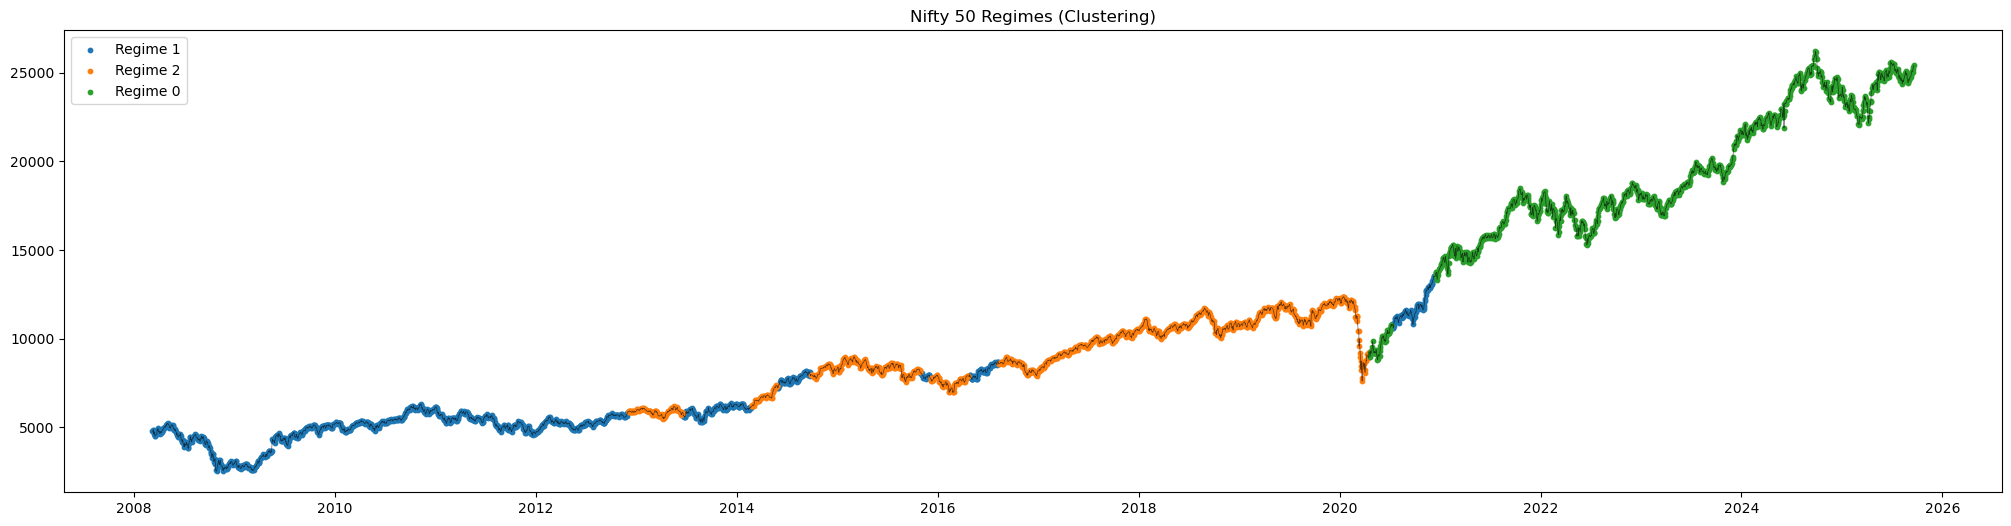

In [96]:
plt.figure(figsize=(25,6))
for c in val_df['Cluster'].dropna().unique():
    mask = val_df['Cluster'] == c
    plt.scatter(val_df.index[mask], val_df['Close'][mask], label=f"Regime {c}", s=10)
plt.plot(val_df.index, val_df['Close'], color='black', linewidth=0.5, alpha=0.6)
plt.title("Nifty 50 Regimes (Clustering)")
plt.legend()
plt.show()

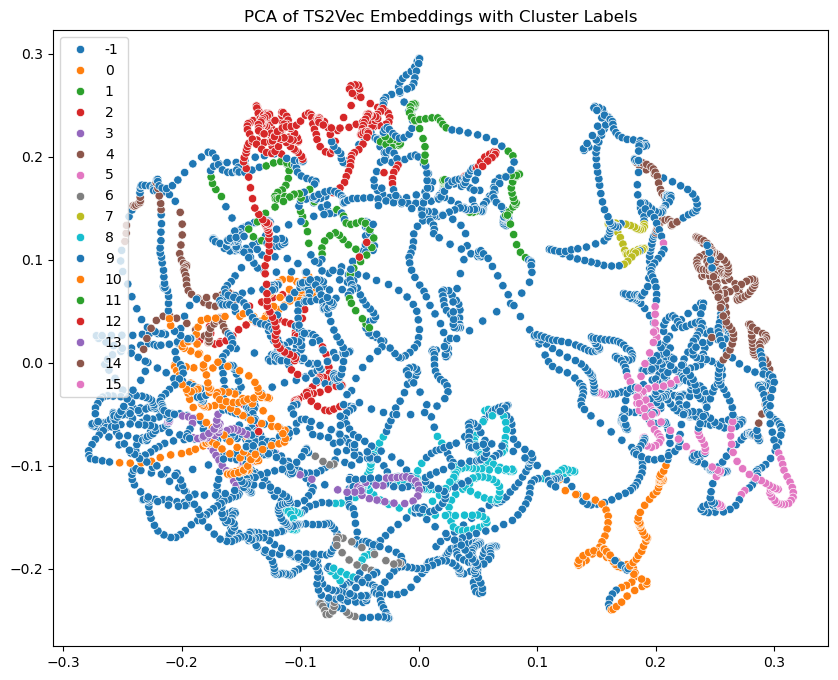

In [81]:
# implement PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_full)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, palette="tab10", legend="full")
plt.title("PCA of TS2Vec Embeddings with Cluster Labels")
plt.show()

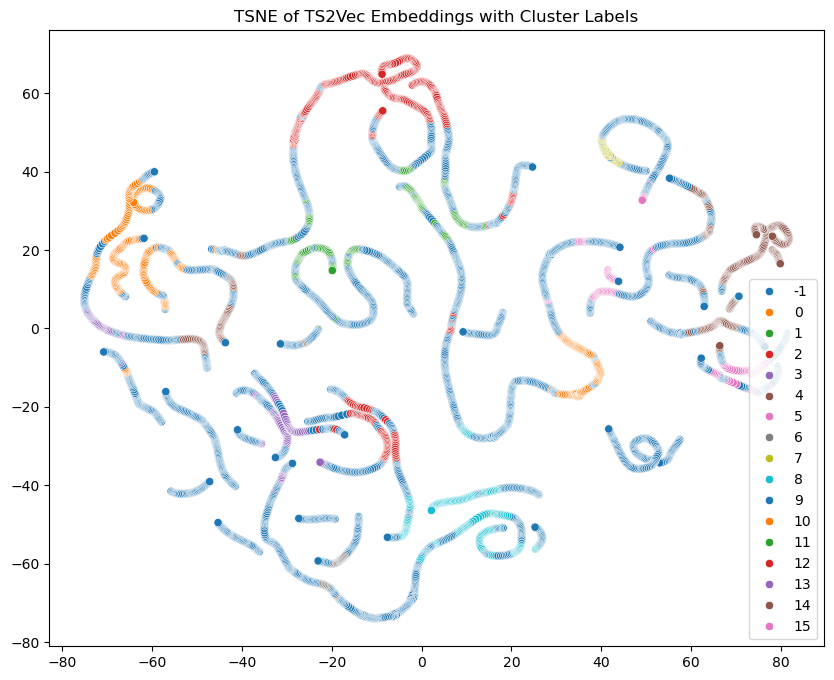

In [82]:
# import TSNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
embeddings_tsne = tsne.fit_transform(embeddings_full)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_tsne[:, 0], y=embeddings_tsne[:, 1], hue=labels, palette="tab10", legend="full")
plt.title("TSNE of TS2Vec Embeddings with Cluster Labels")
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


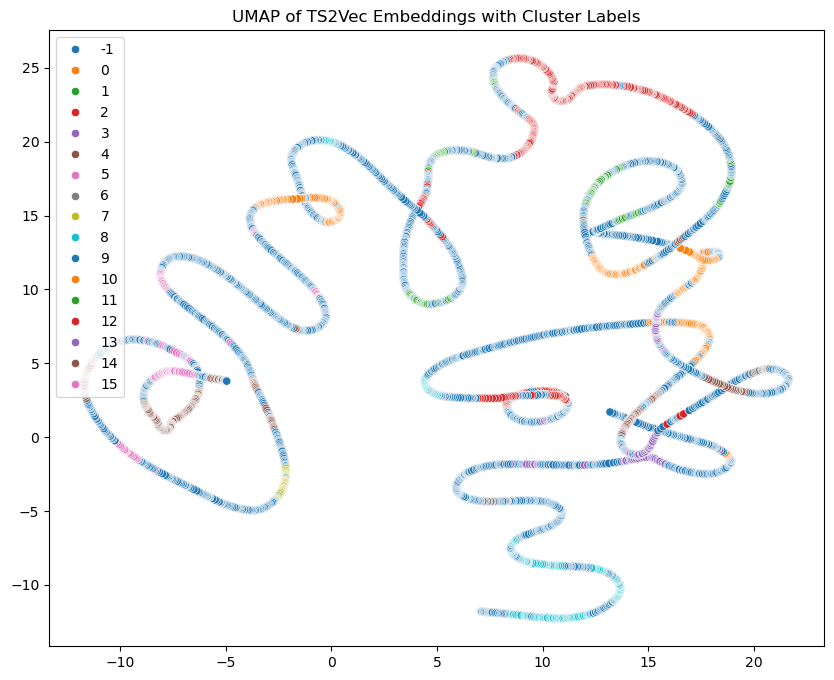

In [84]:
# implement umap for visualization
import umap
reducer = umap.UMAP( n_jobs=-1)
embeddings_umap = reducer.fit_transform(embeddings_full)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_umap[:, 0], y=embeddings_umap[:, 1], hue=labels, palette="tab10", legend="full")
plt.title("UMAP of TS2Vec Embeddings with Cluster Labels")
plt.show()